Time Step 0: Ocean currents updated.
Time Step 10: Ocean currents updated.
Time Step 20: Ocean currents updated.
Time Step 30: Ocean currents updated.
Time Step 40: Ocean currents updated.
Time Step 50: Ocean currents updated.
Time Step 60: Ocean currents updated.
Time Step 70: Ocean currents updated.
Time Step 80: Ocean currents updated.
Time Step 90: Ocean currents updated.
Time Step 99: Ocean currents updated.


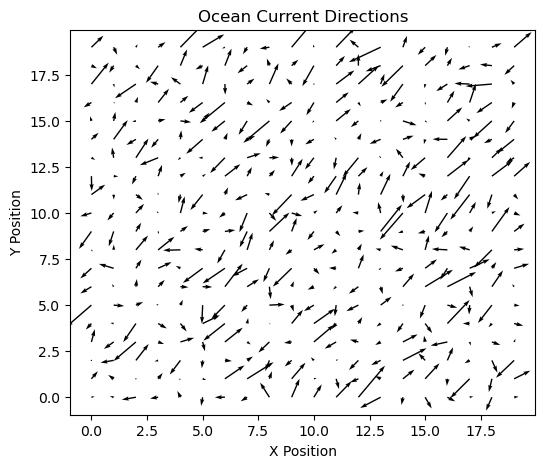

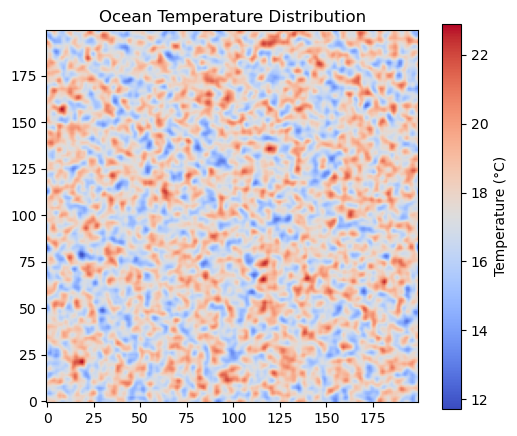

Simulation complete.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Grid size 
grid_size = 200  
TIME_STEPS = 100
# Initialize temperature field (random values between 5C and 30C)
temperature = np.random.uniform(5, 30, size=(grid_size, grid_size))
# Initialize velocity fields (u: x-direction, v: y-direction)
u_velocity = np.random.uniform(-1, 1, size=(grid_size, grid_size))
v_velocity = np.random.uniform(-1, 1, size=(grid_size, grid_size))
# Initialize wind influence (adds turbulence)
wind = np.random.uniform(-0.5, 0.5, size=(grid_size, grid_size))
def laplacian(field):
    
    lap = (np.roll(field, shift=1, axis=0) +
        np.roll(field, shift=-1, axis=0) +
        np.roll(field, shift=1, axis=1) +
        np.roll(field, shift=-1, axis=1)- 4 * field )
    return lap

def update_ocean(u, v, temperature, wind, alpha=0.1, beta=0.02):
    """Updates ocean velocity and temperature fields using a 
simplified flow model."""   
    u_new = u + alpha * laplacian(u) + beta * wind
    v_new = v + alpha * laplacian(v) + beta * wind
    temperature_new = temperature + 0.01 * laplacian(temperature)  # Small diffusion
    return u_new, v_new, temperature_new
# Run the simulation
for t in range(TIME_STEPS):
    u_velocity, v_velocity, temperature = update_ocean(u_velocity, 
v_velocity, temperature, wind)
    if t % 10 == 0 or t == TIME_STEPS - 1:
        print(f"Time Step {t}: Ocean currents updated.")
# Plot the velocity field
plt.figure(figsize=(6, 5))
plt.quiver(u_velocity[::10, ::10], v_velocity[::10, ::10])
plt.title("Ocean Current Directions")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.show()
# Plot temperature distribution
plt.figure(figsize=(6, 5))
plt.imshow(temperature, cmap='coolwarm', origin='lower')
plt.colorbar(label="Temperature (°C)")
plt.title("Ocean Temperature Distribution")
plt.show()
print("Simulation complete.")

In [3]:
from dask.distributed import Client
client = Client()
print(client)
print("Dashboard:", client.dashboard_link)

<Client: 'tcp://127.0.0.1:58202' processes=4 threads=8, memory=7.86 GiB>
Dashboard: http://127.0.0.1:8787/status


LET'S DASK IT!!

In [7]:
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt
import time

grid_size = 200
TIME_STEPS = 100
chunks = (50, 50)
temperature = da.random.uniform(5, 30, size=(grid_size, grid_size), 
chunks=chunks)
u_velocity  = da.random.uniform(-1, 1, size=(grid_size, grid_size), 
chunks=chunks)
v_velocity  = da.random.uniform(-1, 1, size=(grid_size, grid_size), 
chunks=chunks)
wind        = da.random.uniform(-0.5, 0.5, size=(grid_size, 
grid_size), chunks=chunks)


In [8]:
# NumPy Laplacian 
def laplacian_numpy(field):
    return (
        np.roll(field, 1, axis=0)
        + np.roll(field, -1, axis=0)
        + np.roll(field, 1, axis=1)
        + np.roll(field, -1, axis=1)
        - 4 * field
    )
def laplacian_dask(field):
    return da.map_overlap(
        laplacian_numpy,
        field,
        depth=1,           # ghost cell layer
        boundary='reflect' # mirror edges
    )
def update_ocean(u, v, temperature, wind, alpha=0.1, beta=0.02):
    u_new = u + alpha * laplacian_dask(u) + beta * wind
    v_new = v + alpha * laplacian_dask(v) + beta * wind
    temperature_new = temperature + 0.01 * laplacian_dask(temperature)
    return u_new, v_new, temperature_new
# Run simulation
start = time.time()
for t in range(TIME_STEPS):
    u_velocity, v_velocity, temperature = update_ocean(
        u_velocity, v_velocity, temperature, wind
    )
    
    if t % 10 == 0:
        u_velocity, v_velocity, temperature = da.compute(
            u_velocity, v_velocity, temperature
        )
        u_velocity  = da.from_array(u_velocity,  chunks=chunks)
        v_velocity  = da.from_array(v_velocity,  chunks=chunks)
        temperature = da.from_array(temperature, chunks=chunks)
        print(f"Computed timestep {t}")
# Final compute
u_velocity, v_velocity, temperature = da.compute(
    u_velocity, v_velocity, temperature
)
end = time.time()
print("Execution time:", end - start)

Computed timestep 0
Computed timestep 10
Computed timestep 20


KeyboardInterrupt: 

while this happens, ARE YOU EXCITED FOR THE ANTI-MATTER FACTORY!!!?

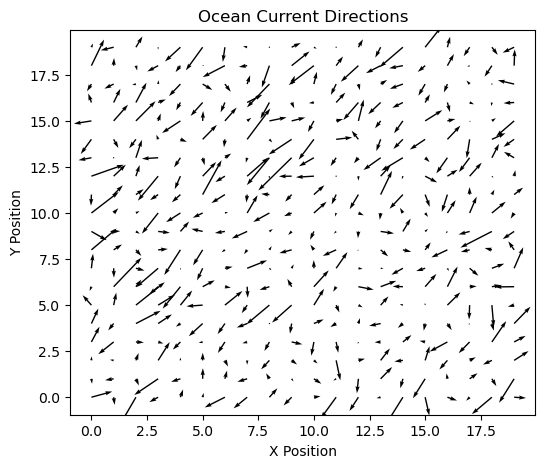

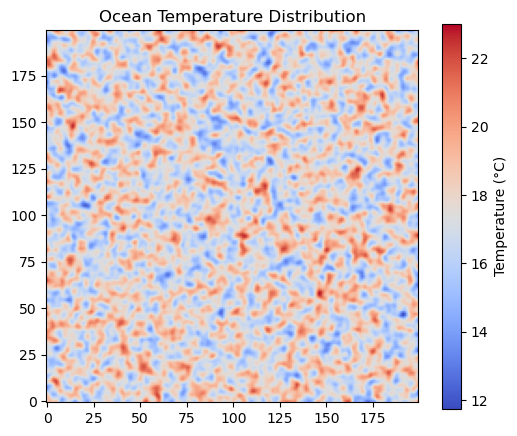

In [6]:
plt.figure(figsize=(6,5))
plt.quiver(u_velocity[::10,::10], v_velocity[::10,::10])
plt.title("Ocean Current Directions")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.show()
# Plot temperature distribution
plt.figure(figsize=(6,5))
plt.imshow(temperature, cmap="coolwarm", origin="lower")
plt.colorbar(label="Temperature (°C)")
plt.title("Ocean Temperature Distribution")
plt.show()

Change the chunks (50 x 50, 100 x 100, 200 x 200), what is your observation?
How does the memory be distributed?

What happened to the memory if you have chunk size 200 x 200?

client has to start before you run your program, if you accidently close it while the program running, click on the link again. 

or client.close()
then run the cells again!